|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 7:</h2>|<h1>Modern vLLM<h1>|
|<h2>Section:</h2>|<h1>Speculative decoding<h1>|
|<h2>Lecture:</h2>|<h1><b>Thirty-two guesses for the price of one<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# The check costs almost nothing, so guess

Part 1 said that a decode step reads every weight to make one token. It also
said that the arithmetic is a rounding error next to the read.

So give the model **eight** tokens in the place of one. The step reads the
weights one time in both cases.

In [2]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-1.7B')
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-1.7B', dtype=torch.bfloat16).cuda().eval()
with torch.no_grad():
  context = torch.randint(0, 1000, (1, 512), device='cuda')
  past_kv = model(context, use_cache=True, logits_to_keep=1).past_key_values

draft_lengths = [1, 2, 4, 8, 16, 32]
verify_times_ms = []
for num_draft in draft_lengths:
  draft_tokens = torch.randint(0, 1000, (1, num_draft), device='cuda')
  with torch.no_grad():
    verify_times_ms.append(cudalib.bench_ms(
        lambda: model(draft_tokens, past_key_values=copy.copy(past_kv), use_cache=True),
        iters=10, warmup=3, best_of=2))
print(f"{'tokens checked':>15} {'ms':>8} {'vs 1':>7}")
for num_draft, time_ms in zip(draft_lengths, verify_times_ms):
  print(f'{num_draft:>15} {time_ms:>8.2f} {time_ms/verify_times_ms[0]:>6.2f}x')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 15720.17it/s]

 tokens checked       ms    vs 1
              1    13.01   1.00x
              2    14.92   1.15x
              4    14.73   1.13x
              8    15.50   1.19x
             16    16.80   1.29x
             32    19.68   1.51x


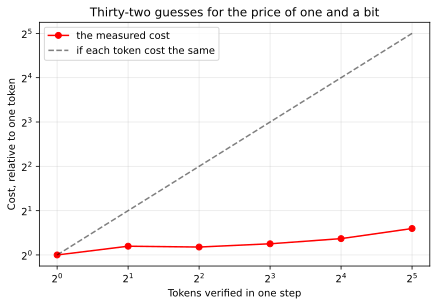

In [3]:
plt.figure(figsize=(7,4.4))
plt.plot(draft_lengths, np.array(verify_times_ms)/verify_times_ms[0], 'ro-',
         label='the measured cost')
plt.plot(draft_lengths, draft_lengths, 'k--', alpha=.5,
         label='if each token cost the same')
plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Tokens verified in one step')
plt.ylabel('Cost, relative to one token')
plt.title('Thirty-two guesses for the price of one and a bit')
plt.legend()
plt.grid(alpha=.3)
plt.show()

So use something cheap to **guess** the next few tokens. The big model then
checks all of them in one step. It accepts the longest correct prefix and
throws the rest away.

When the guesses are good, you get several tokens for each step. When they are
bad, you get one token, which is what you had before.

# The cheapest possible guesser

Use no [draft](../../GLOSSARY.md#draft) model and no training. Look back through the text for the last
time that these few tokens appeared. Guess the tokens that came after them.

That is an n-gram lookup. It costs microseconds. On the text that people
generate, it works much more often than you expect.

In [4]:
def ngram_propose(tokens, max_draft=4, ngram=3):
  """Find the last earlier match of the final `ngram` tokens.
  -> the max_draft tokens that followed that match."""
  if len(tokens) < ngram:
    return []
  pattern = tuple(tokens[-ngram:])
  for start in range(len(tokens) - ngram - 1, -1, -1):
    if tuple(tokens[start:start+ngram]) == pattern:
      return tokens[start+ngram:start+ngram+max_draft]
  return []

def accepted_prefix(draft, actual):
  """The number of draft tokens that match `actual` before the first miss."""
  count = 0
  for drafted, real in zip(draft, actual):
    if drafted != real:
      break
    count += 1
  return count

def acceptance(text, max_draft=4, ngram=3):
  """Draft at each position of text. -> (tokens accepted, tokens proposed)."""
  token_ids = tokenizer(text, add_special_tokens=False).input_ids
  accepted = proposed = 0
  for position in range(10, len(token_ids) - max_draft):
    draft = ngram_propose(token_ids[:position], max_draft, ngram)
    proposed += len(draft)
    accepted += accepted_prefix(draft, token_ids[position:position+len(draft)])
  return accepted, proposed

cases = {
  'repetitive boilerplate': 'The quick brown fox jumps over the lazy dog. ' * 20,
  'a JSON-ish document':    '{"name": "a", "value": 1}, {"name": "b", "value": 2}, ' * 12,
  'ordinary prose':         ('The history of computing begins long before the '
     'machines we recognise. Mechanical calculators counted taxes and tides; '
     'looms read punched cards; clerks called computers worked arithmetic by '
     'hand in rooms full of noise. What changed was not arithmetic but the '
     'idea that a machine could hold its own instructions, and that those '
     'instructions could be changed without rebuilding anything. Everything '
     'after that is a consequence, including the model reading this sentence.'),
}
for name, text in cases.items():
  accepted, proposed = acceptance(text)
  if proposed == 0:
    print(f'{name:<24} no draft proposed: nothing repeats')
  else:
    print(f'{name:<24} {accepted:>5}/{proposed:<5} accepted  {100*accepted/proposed:5.1f}%')

repetitive boilerplate     732/732   accepted  100.0%
a JSON-ish document        650/1052  accepted   61.8%
ordinary prose           no draft proposed: nothing repeats


Three different answers, and the third one is the important one.

On genuinely novel prose the lookback table never finds a repeated trigram,
so it proposes **nothing at all**. That is not a failure: a draft that is
never made costs nothing and is never wrong. The speculation simply switches
itself off and you are back to ordinary decoding.

Which is why n-gram speculation is worth having even though it looks like a
trick. Summarisation, code completion, JSON output and
retrieval-augmented answers all quote their input heavily, and quoted text is
exactly what a lookback table predicts perfectly. Creative writing gets
nothing, and loses nothing.

# What the acceptance rate is worth

Take K drafted tokens and acceptance rate `acceptance_rate`. The expected number of accepted
tokens for each step is a geometric sum. Use the measured curve above for the
cost of a step, and not 1.

In [5]:
def expected_tokens(acceptance_rate, num_draft):
  """Accept the longest correct PREFIX: a + a^2 + ... + a^K. Add 1 for the
  token that the big model makes at no cost at the end."""
  return sum(acceptance_rate**i for i in range(1, num_draft+1)) + 1

step_cost = {num_draft: time_ms/verify_times_ms[0]
             for num_draft, time_ms in zip(draft_lengths, verify_times_ms)}

def speedup(acceptance_rate, num_draft):
  return expected_tokens(acceptance_rate, num_draft) / step_cost[num_draft]

DRAFTS = (2, 4, 8, 16)
print(f"{'accept':>7} " + ' '.join(f'K={num_draft:<5}' for num_draft in DRAFTS))
for acceptance_rate in (0.2, 0.4, 0.6, 0.8, 0.9):
  cells = [f'{speedup(acceptance_rate, num_draft):5.2f}x' for num_draft in DRAFTS]
  print(f'{acceptance_rate:>7.0%} ' + ' '.join(f'{cell:<7}' for cell in cells))

 accept K=2     K=4     K=8     K=16   
    20%  1.08x   1.10x   1.05x   0.97x 
    40%  1.36x   1.46x   1.40x   1.29x 
    60%  1.71x   2.04x   2.08x   1.94x 
    80%  2.13x   2.97x   3.64x   3.79x 
    90%  2.36x   3.62x   5.14x   6.45x 


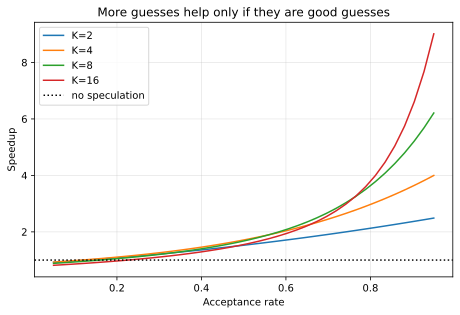

K=  2: you need 14% acceptance before this is worth it
K=  4: you need 12% acceptance before this is worth it
K=  8: you need 17% acceptance before this is worth it
K= 16: you need 23% acceptance before this is worth it


In [6]:
acceptance_rates = np.linspace(0.05, 0.95, 40)
plt.figure(figsize=(7.5,4.6))
for num_draft in DRAFTS:
  plt.plot(acceptance_rates, [speedup(rate, num_draft) for rate in acceptance_rates],
           label=f'K={num_draft}')
plt.axhline(1.0, color='k', ls=':', label='no speculation')
plt.xlabel('Acceptance rate')
plt.ylabel('Speedup')
plt.title('More guesses help only if they are good guesses')
plt.legend()
plt.grid(alpha=.3)
plt.show()
for num_draft in DRAFTS:
  break_even = next((rate for rate in acceptance_rates if speedup(rate, num_draft) > 1.0), None)
  print(f'K={num_draft:>3}: you need {break_even:.0%} acceptance before this is worth it')

### And the part that is not a speed trick

When you accept a token because the draft guessed it, you change **which token
you emit**. A naive implementation of speculative decoding is a different
sampler with a different output distribution. That is not a speedup. That is a
different model.

The fix has a name: [modified rejection sampling](../../GLOSSARY.md#rejection-sampling). Accept the drafted token with
probability `min(1, p_target/p_draft)`. On a rejection, sample from the
normalised difference `max(0, p_target - p_draft)`.

The result is **exactly** the target distribution. There is a proof, and it
holds for all draft models, even a very bad one.

That property makes this method safe to deploy. You can ship a bad draft model
and lose speed. You cannot ship one that changes the answers.

Stage 17 makes you implement it. It also makes you prove that the distribution
does not change, with a chi-squared test and not with the derivation.

    ./vc guide 17